In [3]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

model = ChatGoogleGenerativeAI(model='gemini-3-flash-preview')

C:\Users\manoj\PycharmProjects\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
MAX_TOKENS = 150

In [6]:
def call_model(state: MessagesState):

    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [7]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [8]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

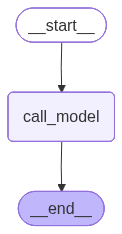

In [9]:
graph

In [10]:
config = {"configurable": {"thread_id": "chat-1"}}
input = {"messages": [{"role": "user", "content": "Hi, my name is Manoj."}]}
result = graph.invoke(input=input, config=config)

Current Token Count -> 10
Hi, my name is Manoj.


In [11]:
result["messages"][-1].content[0]['text']

"Hello, Manoj! It's nice to meet you. How can I help you today?"

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content[0]['text']

Current Token Count -> 41
Hi, my name is Manoj.
[{'type': 'text', 'text': "Hello, Manoj! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'EqQCCqECAQw51sc7hZixJp22wQXvSVhGPT1ct4HiaW0jUw+76wIViIZQsorbyEfvZ9gIj/BO/0TxAUuYNOCxtM09zmdwXOXpaYzdX4Ce5stvDEQyFUXCQAiG87OB6SufZFM6ojFINmPldpbo0ejpn/6oZnJnTbz71dUQ749R2gOcoIuCXTcuGu8Z9yn62Mu4n8UCGRhK2NB9uZY8BhdjVDgs+hWt+q3WNEcIJROR/cvi36nQ2g2LA+9SKqpdrdz92WyQIz7HcnU+Nsf/R93vXzDvhEeAxFlopKynThkVoBgPtusDLF22mqaU4TO7N/t+xS/cNF5lYhEcXAR0R6Q9cUZc9PktqbbnRh5vsmjm1IC+lTaHH3b0/iNPFiC/rEWmXcj8iPEvaw=='}}]
I am learning LangGraph.


'That’s awesome, Manoj! LangGraph is a fantastic choice if you want to build complex, stateful AI agents. It’s essentially the next evolution of LangChain, designed specifically to handle **cycles** (loops) and **state management**, which are often tricky in standard linear chains.\n\nSince you are just starting, it helps to focus on the three core building blocks:\n\n### 1. The Key Concepts\n*   **State:** A shared database (usually a TypedDict or Pydantic model) that all parts of your graph can read from and write to.\n*   **Nodes:** These are just Python functions. They take the current `State` as input, do something (like call an LLM or a tool), and return an update to the `State`.\n*   **Edges:** These define the path between nodes. \n    *   *Normal Edges:* Go from Node A to Node B.\n    *   *Conditional Edges:* Use logic (if/else) to decide which node to go to next (e.g., "If the LLM provided an answer, go to END; if it needs a tool, go to the Tool Node").\n\n### 2. Why LangGrap

In [13]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content[0]['text']

Current Token Count -> 13
Can you explain short term memory?


'Short-term memory (STM) is often described as the **"scratchpad"** or the "post-it note" of the human mind. it is the phase of memory that holds a small amount of information in an active, readily available state for a very short period.\n\nHere is a breakdown of how it works, its limits, and how it differs from other types of memory.\n\n---\n\n### 1. The Two Main Constraints\nShort-term memory is defined by two major limitations: **Duration** and **Capacity.**\n\n*   **Duration (How long?):** Without active effort, information in short-term memory lasts about **15 to 30 seconds**. If you don\'t repeat the information to yourself (rehearsal), it fades away almost immediately.\n*   **Capacity (How much?):** Historically, psychologists (specifically George Miller) argued that humans can hold about **7 items, plus or minus 2**. Modern research suggests it may be even smaller—closer to **4 or 5 "chunks"** of information.\n\n### 2. Key Techniques: Rehearsal and Chunking\nBecause STM is so 

In [14]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content[0]['text']

Current Token Count -> 8
What is my name?


'I don’t know your name because I don’t have access to your personal information or identity unless you tell me.\n\nIf you’d like, you can tell me your name, and I’ll remember it for this conversation!'

In [15]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Manoj.
------------------------------------------------------------------------------------------------------------------------
[{'type': 'text', 'text': "Hello, Manoj! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'EqQCCqECAQw51sc7hZixJp22wQXvSVhGPT1ct4HiaW0jUw+76wIViIZQsorbyEfvZ9gIj/BO/0TxAUuYNOCxtM09zmdwXOXpaYzdX4Ce5stvDEQyFUXCQAiG87OB6SufZFM6ojFINmPldpbo0ejpn/6oZnJnTbz71dUQ749R2gOcoIuCXTcuGu8Z9yn62Mu4n8UCGRhK2NB9uZY8BhdjVDgs+hWt+q3WNEcIJROR/cvi36nQ2g2LA+9SKqpdrdz92WyQIz7HcnU+Nsf/R93vXzDvhEeAxFlopKynThkVoBgPtusDLF22mqaU4TO7N/t+xS/cNF5lYhEcXAR0R6Q9cUZc9PktqbbnRh5vsmjm1IC+lTaHH3b0/iNPFiC/rEWmXcj8iPEvaw=='}}]
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
[{'type': 'text', 'text': 'That’s awesome, Manoj! LangGraph is a fantast